# Project Analysis

This runs the analysis part of our project. First, we read all the data into dataframe. Then we analyze the changes over time, and finally produce a fractional heatmap to incdicate in how much of the releases each capability appear (meaning 1.0 = 100%, in all analyzed releases this capability appeared, and 0.0 = 0%, in none of the analyzed releases this capability appeared). 

In [1]:
import json
import pathlib
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
results_dir = pathlib.Path("../results")
rows = []
tot_num_revisions = 0
for repo_dir in sorted(results_dir.iterdir()):
    # iterate over all versions of this repo
    for json_file in repo_dir.glob("*.json"):
        # check if an error.log exists, if it does, then we skip this version (since it failed)
        if (repo_dir / f"{json_file.stem}.error.log").exists():
            print(f"Skipping failed {repo_dir} at tag {json_file.stem}")
            continue

        # if json file is empty, something is also wrong
        with open(json_file, "r") as f:
            # read first character
            fchar = f.read(1)

            if not fchar:
                print(f"Skipping empty {repo_dir} at tag {json_file.stem}")
                continue

        tot_num_revisions = tot_num_revisions + 1

        # read the raw json data from file
        with open(json_file) as f:
            raw = json.load(f)

        # iterate over all capabilities and add them to our "rows"
        for cap in raw.get("capabilityInfo", []):
            rows.append(
                {
                    "repo": repo_dir.name.replace("_", "/"),
                    "tag": json_file.stem,
                    "capability": cap["capabilityName"],
                    "package_dir": cap["packageDir"],
                    "capability_type": cap["capabilityType"],
                    "depth": len(cap["path"]),
                }
            )

df = pd.DataFrame(rows)
print(f"Loaded {df['repo'].nunique()} repos with total of {tot_num_revisions} releases")

Skipping failed ../results/beego_beego at tag v2.3.10
Skipping failed ../results/beego_beego at tag v2.0.7
Skipping failed ../results/beego_beego at tag v1.12.14
Skipping failed ../results/beego_beego at tag v2.2.2
Skipping failed ../results/beego_beego at tag v2.1.6
Skipping failed ../results/go-chi_chi at tag v4.1.3
Skipping failed ../results/go-kit_kit at tag v0.9.0
Skipping failed ../results/golang_protobuf at tag v1.1.0
Skipping failed ../results/golang_protobuf at tag v1.2.0
Skipping failed ../results/gorilla_mux at tag v1.6.2
Skipping failed ../results/gorilla_mux at tag v1.5.0
Skipping failed ../results/gorilla_mux at tag v1.4.0
Skipping failed ../results/gorilla_websocket at tag v1.1.0
Skipping failed ../results/gorilla_websocket at tag v1.3.0
Skipping failed ../results/gorilla_websocket at tag v1.2.0
Skipping failed ../results/json-iterator_go at tag 1.0.6
Skipping failed ../results/julienschmidt_httprouter at tag v1.1.0
Skipping failed ../results/julienschmidt_httprouter at 

In [3]:
df

,repo,tag,capability,package_dir,capability_type,depth
0,IBM/sarama,v1.45.2,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,5
1,IBM/sarama,v1.45.2,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,10
2,IBM/sarama,v1.45.2,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,7
3,IBM/sarama,v1.45.2,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,5
4,IBM/sarama,v1.45.2,FILES,github.com/IBM/sarama,CAPABILITY_TYPE_DIRECT,6
...,...,...,...,...,...,...
511466,zeromicro/go-zero,v1.10.1,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,15
511467,zeromicro/go-zero,v1.10.1,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,15
511468,zeromicro/go-zero,v1.10.1,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,16
511469,zeromicro/go-zero,v1.10.1,EXEC,github.com/zeromicro/go-zero/zrpc/resolver/int...,CAPABILITY_TYPE_TRANSITIVE,15


In [4]:
import re


def semver_key(tag):
    m = re.match(r"v?(\d+)\.(\d+)\.(\d+)", tag)
    return (int(m.group(1)), int(m.group(2)), int(m.group(3))) if m else (0, 0, 0)


def load_cap_entries(repo_dir, tag):
    """Returns list of capabilityInfo dicts from raw JSON."""
    json_file = repo_dir / f"{tag}.json"
    with open(json_file) as f:
        return json.load(f).get("capabilityInfo", [])


def best_path_for_cap(entries, cap_name):
    """Return one representative entry: prefer DIRECT, then shortest depPath."""
    matching = [e for e in entries if e["capabilityName"] == cap_name]
    if not matching:
        return None
    direct = [
        e for e in matching if e.get("capabilityType") == "CAPABILITY_TYPE_DIRECT"
    ]
    candidates = direct if direct else matching
    return min(candidates, key=lambda e: len(e.get("depPath", "")))


for repo, group in df.groupby("repo"):
    repo_dir = results_dir / repo.replace("/", "_")
    tags = sorted(group["tag"].unique(), key=semver_key)

    cap_sets = {
        tag: set(group[group["tag"] == tag]["capability"].unique()) for tag in tags
    }

    for prev, curr in zip(tags, tags[1:]):
        added = cap_sets[curr] - cap_sets[prev]
        removed = cap_sets[prev] - cap_sets[curr]

        if not (added or removed):
            continue

        print(f"{repo}: {prev} → {curr}")

        if added:
            print(f"  ADDED:   {added}")
            entries = load_cap_entries(repo_dir, curr)
            for cap in sorted(added):
                best = best_path_for_cap(entries, cap)
                if best:
                    print(f"    [{cap}] {best['packageDir']}")
                    print(f"      via: {best.get('depPath', '')}")

        if removed:
            print(f"  REMOVED: {removed}")

IBM/sarama: v1.47.0 → v1.48.2
  ADDED:   {'SYSTEM_CALLS'}
    [SYSTEM_CALLS] github.com/IBM/sarama
      via: github.com/IBM/sarama.getTCPConnSockError$1 golang.org/x/sys/unix.GetsockoptInt
charmbracelet/bubbletea: v1.3.10 → v2.0.6
  ADDED:   {'UNSAFE_POINTER'}
    [UNSAFE_POINTER] charm.land/bubbletea/v2
      via: (*charm.land/bubbletea/v2.cursedRenderer).flush (*github.com/charmbracelet/ultraviolet.StyledString).Draw github.com/charmbracelet/ultraviolet.printString[string] (*github.com/charmbracelet/x/ansi.Parser).Params
charmbracelet/lipgloss: v1.0.0 → v1.1.0
  ADDED:   {'UNSAFE_POINTER', 'UNANALYZED'}
    [UNANALYZED] github.com/charmbracelet/lipgloss
      via: (github.com/charmbracelet/lipgloss.Style).Render github.com/charmbracelet/x/cellbuf.Wrap github.com/charmbracelet/x/ansi.GetParser (*sync.Pool).Get
    [UNSAFE_POINTER] github.com/charmbracelet/lipgloss
      via: (github.com/charmbracelet/lipgloss.Style).Render github.com/charmbracelet/x/cellbuf.Wrap (*github.com/charmbra

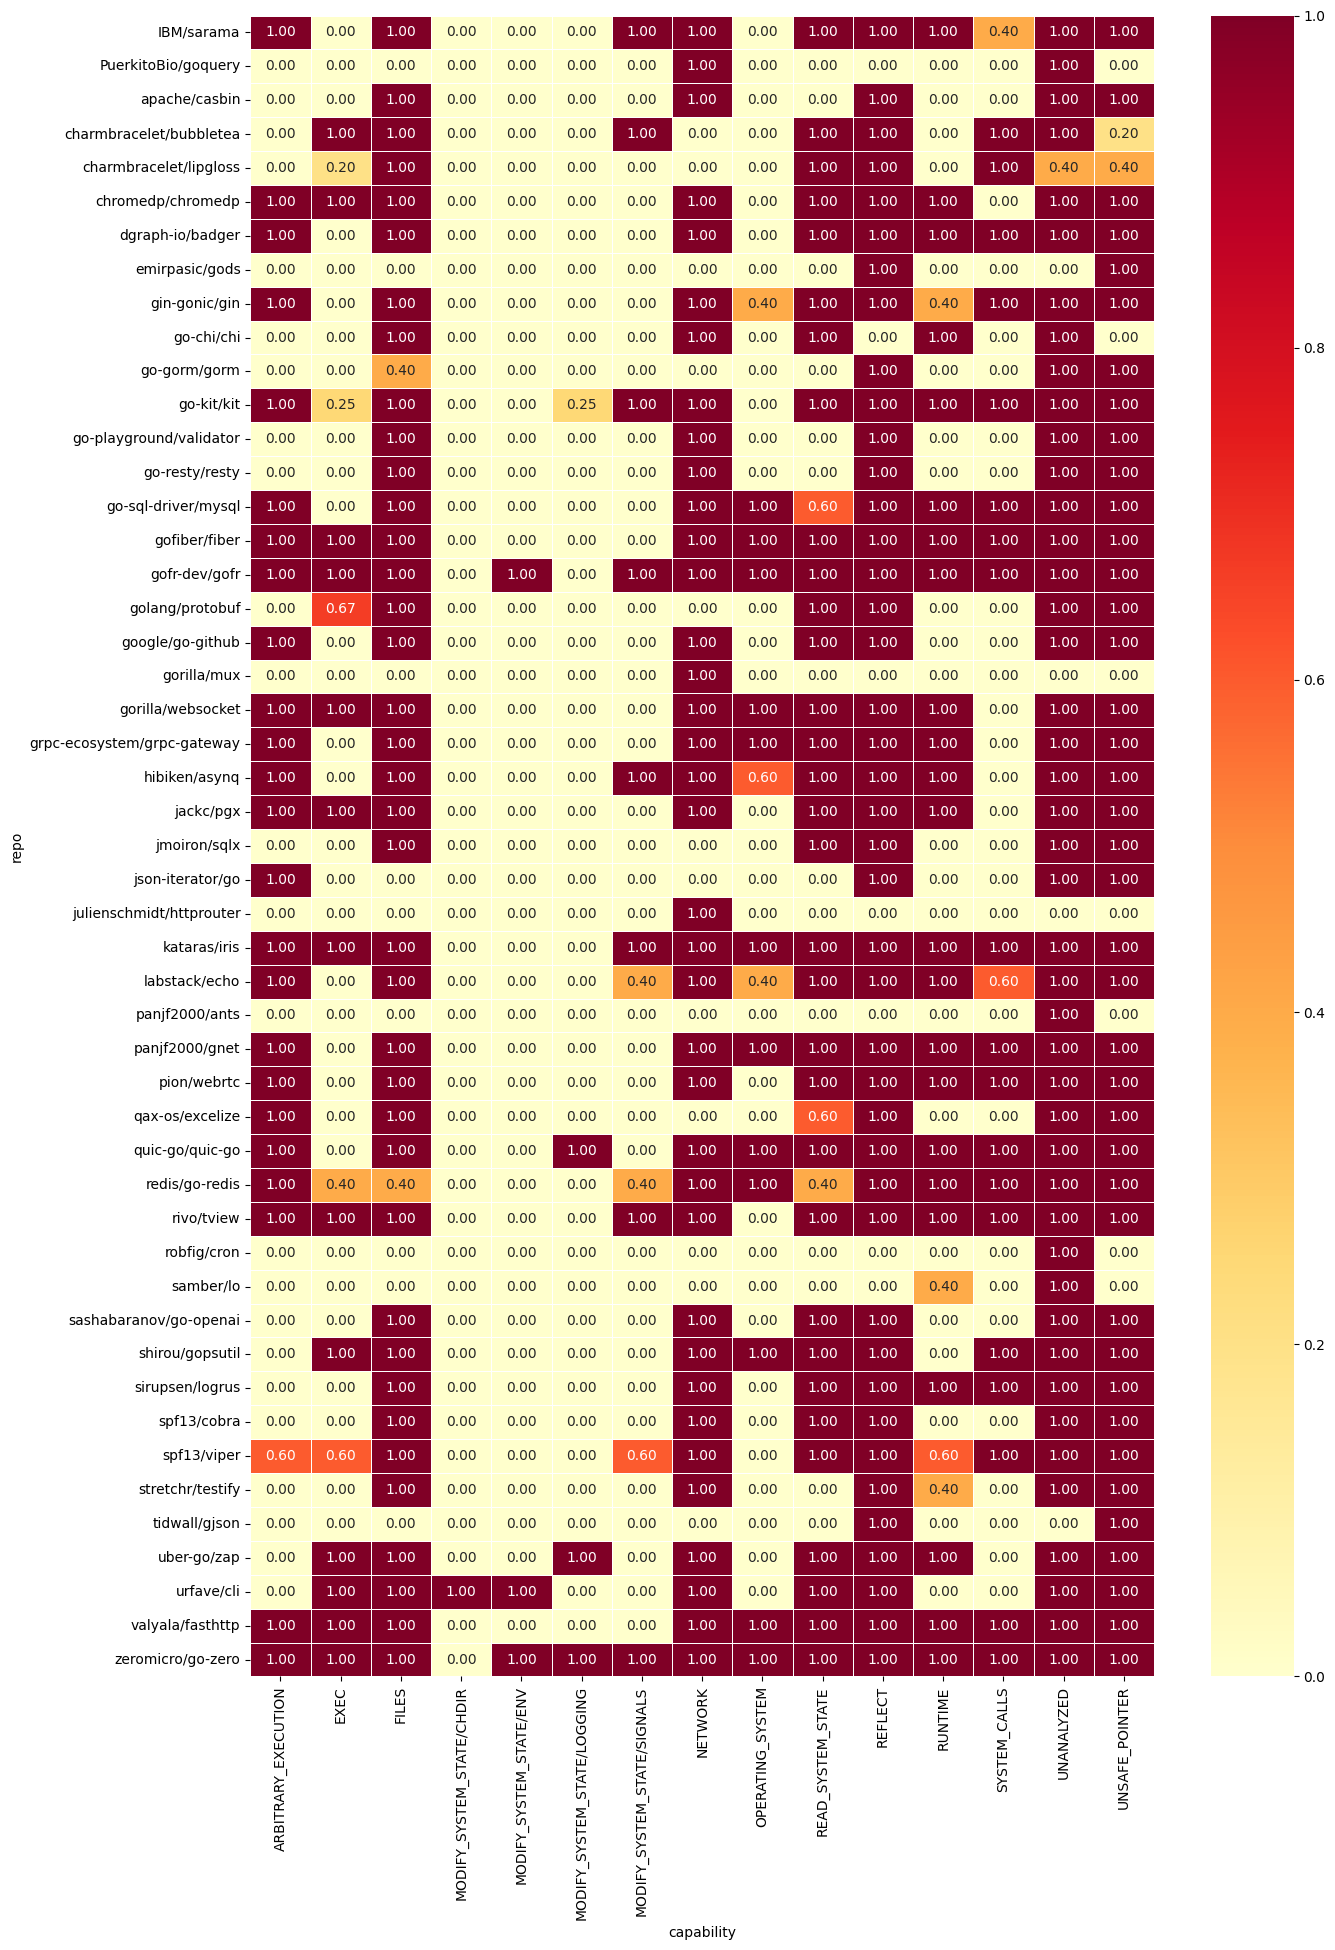

In [5]:
# pivot = df.groupby(["repo", "capability"]).size().unstack(fill_value=0)
# pivot = (
#     df.groupby(["repo", "capability"]).size().unstack(fill_value=0).gt(0).astype(int)
# )
pivot = (
    df.groupby(["repo", "capability"])["tag"].nunique()
    / df.groupby("repo")["tag"].nunique()
).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, len(pivot) * 0.4))
# sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.5, annot=True, fmt="d")
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.5, annot=True, fmt=".2f")
plt.tight_layout()
plt.savefig("heatmap_capability_fraction.png", dpi=300, bbox_inches="tight")
plt.show()